### Setup and imports

In [ ]:
import pandas as pd
import numpy as np
import rdkit
import ast
import matplotlib.pyplot as plt
# Fixed-grid multi-label logistic regression baseline.
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import ast

#add future imports here

In [ ]:
labelled_df = pd.read_csv(r"data/IR spectroscopy data/SMILES_IR_Spectroscopy.csv", low_memory=False)

In [ ]:
def plot_graph(row):
    x_coords = row["x_coords"]
    y_coords = row["y_coords"]

    if isinstance(x_coords, str):
        x_coords = ast.literal_eval(x_coords)
    if isinstance(y_coords, str):
        y_coords = ast.literal_eval(y_coords)

    plt.figure(figsize=(10, 4))
    plt.plot(x_coords, y_coords, linewidth=1)
    plt.xlabel("1/cm")
    plt.ylabel("Absorbance")
    plt.title(row.get("smiles", "IR Spectrum"))
    plt.tight_layout()
    plt.show()
    return None

In [ ]:
#test it
plot_graph(labelled_df.iloc[0])
for i in range(15):
    print("================")
    plot_graph(labelled_df.iloc[i])

## Normalization of data

### Standardize spectra through interpolating coordinate data to fixed grid 
* Using indiviail based normalizaiton and not group global normalization because:
  * experimental conditions may not have been consistant
  * the model learns scale artifacts (instrument, concentration) which makes it worse at generalization

In [ ]:
#temp. perform normalization on small sample of data for computation
test_df = labelled_df.sample(500)

In [ ]:
#test it
for i in range(5):
    print(f'====regular{i}=====')
    plot_graph(labelled_df.iloc[i])
    print(f'====normalized{i}=====')
    plot_graph(normalized_y_df.iloc[i])
    print(f'===================')

## Labeling

### Canonicallize smiles 
* learn more at 
  * https://luis-vollmers.medium.com/tutorial-to-smiles-and-canonical-smiles-explained-with-examples-fbc8a46ca29f

In [ ]:
#Smiles canonicalization implementation
from rdkit import Chem

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

normalized_y_df['canonical_smiles'] = normalized_y_df['smiles'].apply(canonicalize_smiles)
canonicalized_smiles_df = normalized_y_df
print(f"Successfully canonicalized: {canonicalized_smiles_df['canonical_smiles'].notna().sum()} our of {len(canonicalized_smiles_df)}")
canonicalized_smiles_df.head()

### Create Labels 
* using martini 3 mapping algorithm to label compounds from smiles
* refer to paper 

In [12]:
# Load the labelled data and add derivative channels for the CNN.
labelled_df = pd.read_csv("/home/mmalik/Documents/Projects/CscSpring26/CSC_4444/CSC4444_Project/Organic-Compound-Classifier/data/IR spectroscopy data/Labelled_SMILES_IR_Spectroscopy.csv")

## Baseline Modeling

* set an initial comparison point for assessing the performance of more complex models.

## Main Model

### Train a 1D CNN with Multi-Task Outputs
* hyper parameters and justification
  * using cross entropy loss function for multi classification
  * in channels: spectroscopy (x,y) pair coordinate values, first derivative of coordinate, second derivative of coordinate 
  * out channel: list of beads with probability attached. Note there could be multiple beeds and multiple beed of the same type ex: [N: 0.67, C5: 0.23, C5: 0.02, N4: 0.93, C5: 0.21, C5: 0.11, C5: 0.87, C5: 0.21]
  * kernel size sohuld very and we will see which is best with evaluations
  * validtion dataset will be used to help backpropagate parameters
  

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

labelled_df['bead_list'] = labelled_df['bead_summary'].apply(lambda x: [b.strip() for b in x.split(',')] if isinstance(x, str) else [])

mlb = MultiLabelBinarizer()
bead_labels = mlb.fit_transform(labelled_df['bead_list'])

print(f"Number of unique bead types: {len(mlb.classes_)}")
print(f"Bead types: {mlb.classes_}")
print(f"Label matrix shape: {bead_labels.shape}")

Number of unique bead types: 23
Bead types: ['C1' 'C2' 'C3' 'C4' 'C5' 'C6' 'N1' 'N2' 'N3' 'N4' 'N5' 'N6' 'P1' 'P2'
 'P3' 'P4' 'P5' 'P6' 'Q4' 'X1' 'X2' 'X3' 'X4']
Label matrix shape: (7910, 23)


In [19]:
def interpolate_spectrum(row,target_length=3600):
    x = ast.literal_eval(row['x_coords']) if isinstance(row['x_coords'], str) else row['x_coords']
    y = ast.literal_eval(row['y_coords']) if isinstance(row['y_coords'], str) else row['y_coords']
    f = interp1d(x, y, bounds_error=False, fill_value=0)
    x_new = np.linspace(400, 4000, target_length)
    return f(x_new)
    
spectra = np.array([interpolate_spectrum(row) for _, row in labelled_df.iterrows()])
print(f"Spectra shape: {spectra.shape}")

Spectra shape: (7910, 3600)


### Data Splitting
* 80/20 train/test split on labelled data.

In [20]:
X = torch.tensor(spectra, dtype=torch.float32).unsqueeze(1)  
y = torch.tensor(bead_labels, dtype=torch.float32)           # Shape: (7910, 23)

# Train/test split
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset)) #train sample size would be 80% of the dataset
test_size = len(dataset) - train_size #test sample size would be 20% of the dataset
train_set, test_set = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32)

print(f"Training samples: {train_size}")
print(f"Test samples: {test_size}")


Training samples: 6328
Test samples: 1582


In [21]:
class IRBeadClassifier(nn.Module):
    def __init__(self, input_length, num_bead_types):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        conv_output_size = 128 * (input_length // 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_output_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_bead_types),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.classifier(x)

model = IRBeadClassifier(input_length=3600, num_bead_types=23)
print(model)


IRBeadClassifier(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=57600, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=23, bias=True)
    (5): Sigmoid()
  )
)


In [22]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")


Epoch 1/30 | Loss: 0.2508


KeyboardInterrupt: 

## Evaluation
* for results section

In [34]:
model = IRBeadClassifier(input_length=3600, num_bead_types=23)
state_dict = torch.load("/home/mmalik/Documents/Projects/CscSpring26/CSC_4444/CSC4444_Project/Organic-Compound-Classifier/model/ir_bead_classifier.pth")
model.load_state_dict(state_dict)
print(model)

IRBeadClassifier(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=57600, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=23, bias=True)
    (5): Sigmoid()
  )
)


In [35]:
model.eval()

IRBeadClassifier(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=57600, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=23, bias=True)
    (5): Sigmoid()
  )
)

### Evaluate Bead Prediction (Train vs Test F1, Hamming Loss)

Training Hamming Loss: 0.0137
Training F1 Score (micro): 0.9419
Training F1 Score (macro): 0.9219
Training F1 Score (samples): 0.9320
Test Hamming Loss: 0.0140
Test F1 Score (micro): 0.9408
Test F1 Score (macro): 0.8831
Test F1 Score (samples): 0.9326
F1 gap (train - test): 0.0010
Hamming gap (test - train): 0.0003
Result: no strong overfitting signal from these metrics alone.


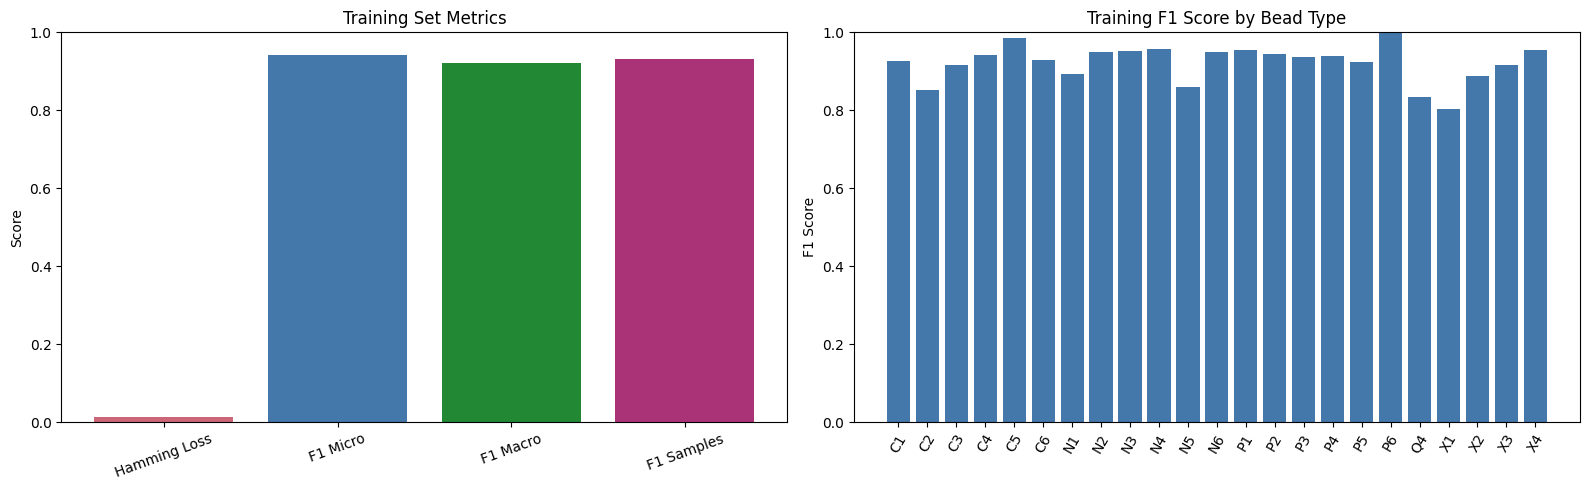

In [40]:
from sklearn.metrics import hamming_loss, f1_score

def evaluate_loader(loader):
    preds = []
    labels = []

    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            batch_preds = model(X_batch)
            preds.append((batch_preds > 0.5).cpu().numpy().astype(int))
            labels.append(y_batch.cpu().numpy().astype(int))

    y_pred = np.concatenate(preds, axis=0)
    y_true = np.concatenate(labels, axis=0)
    return {
        "hamming_loss": hamming_loss(y_true, y_pred),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_samples": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "per_bead_f1": f1_score(y_true, y_pred, average=None, zero_division=0),
    }

device = next(model.parameters()).device
train_metrics = evaluate_loader(train_loader)
test_metrics = evaluate_loader(test_loader)

print(f"Training Hamming Loss: {train_metrics['hamming_loss']:.4f}")
print(f"Training F1 Score (micro): {train_metrics['f1_micro']:.4f}")
print(f"Training F1 Score (macro): {train_metrics['f1_macro']:.4f}")
print(f"Training F1 Score (samples): {train_metrics['f1_samples']:.4f}")
print(f"Test Hamming Loss: {test_metrics['hamming_loss']:.4f}")
print(f"Test F1 Score (micro): {test_metrics['f1_micro']:.4f}")
print(f"Test F1 Score (macro): {test_metrics['f1_macro']:.4f}")
print(f"Test F1 Score (samples): {test_metrics['f1_samples']:.4f}")

f1_gap = train_metrics['f1_micro'] - test_metrics['f1_micro']
loss_gap = test_metrics['hamming_loss'] - train_metrics['hamming_loss']

print(f"F1 gap (train - test): {f1_gap:.4f}")
print(f"Hamming gap (test - train): {loss_gap:.4f}")

if f1_gap >= 0.05 or loss_gap >= 0.05:
    print("Result: possible overfitting. Train performance is noticeably better than test performance.")
else:
    print("Result: no strong overfitting signal from these metrics alone.")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

summary_metrics = [train_metrics['hamming_loss'], train_metrics['f1_micro'], train_metrics['f1_macro'], train_metrics['f1_samples']]
summary_labels = ["Hamming Loss", "F1 Micro", "F1 Macro", "F1 Samples"]
axes[0].bar(summary_labels, summary_metrics, color=["#cc6677", "#4477aa", "#228833", "#aa3377"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Training Set Metrics")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=20)

bead_names = mlb.classes_
axes[1].bar(bead_names, train_metrics['per_bead_f1'], color="#4477aa")
axes[1].set_ylim(0, 1)
axes[1].set_title("Training F1 Score by Bead Type")
axes[1].set_ylabel("F1 Score")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

### todo run some additional tests to determine accuracy for results section of paper
* specific labels
* specific x ranges 
* variance/diversity of output vector
    * use MMR eval

### Calibration and Confidence Analysis
* using temperature scaling

Learned temperature: 1.6225
Raw test confidence summary:
  Mean confidence: 0.1135
  Decision confidence: 0.9885
  Decision accuracy: 0.9860
  NLL: 0.0651
  Brier score: 0.0118
  ECE: 0.0080
Temp-scaled test confidence summary:
  Mean confidence: 0.1131
  Decision confidence: 0.9792
  Decision accuracy: 0.9860
  NLL: 0.0560
  Brier score: 0.0126
  ECE: 0.0109
ECE improvement: -0.0028


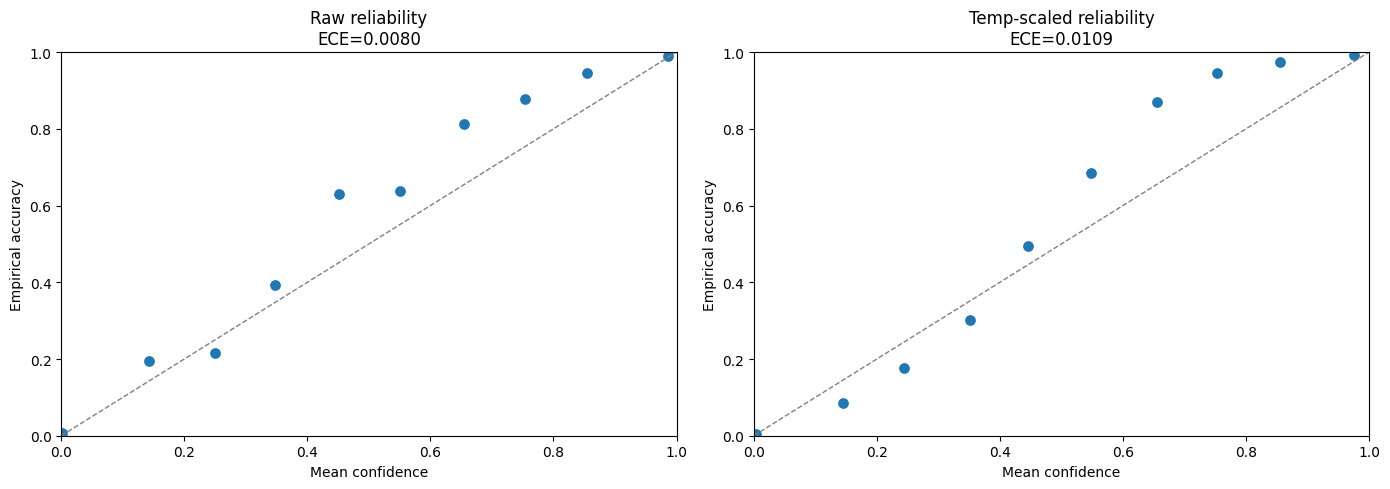

In [41]:
def collect_probabilities(loader):
    all_probs = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            probs = model(X_batch).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y_batch.cpu().numpy())

    return np.concatenate(all_probs, axis=0), np.concatenate(all_labels, axis=0)

def probs_to_logits(probs, eps=1e-6):
    clipped = np.clip(probs, eps, 1.0 - eps)
    return np.log(clipped / (1.0 - clipped))

def apply_temperature(probs, temperature, eps=1e-6):
    logits = probs_to_logits(probs, eps=eps)
    return 1.0 / (1.0 + np.exp(-logits / temperature))

def binary_nll(probs, labels, eps=1e-6):
    clipped = np.clip(probs, eps, 1.0 - eps)
    return float(-np.mean(labels * np.log(clipped) + (1.0 - labels) * np.log(1.0 - clipped)))

def expected_calibration_error(probs, labels, n_bins=10):
    confidence = probs.reshape(-1)
    truth = labels.reshape(-1)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_rows = []

    for left, right in zip(bins[:-1], bins[1:]):
        if right == 1.0:
            mask = (confidence >= left) & (confidence <= right)
        else:
            mask = (confidence >= left) & (confidence < right)

        if not np.any(mask):
            bin_rows.append((left, right, np.nan, np.nan, 0.0))
            continue

        bin_conf = confidence[mask].mean()
        bin_acc = truth[mask].mean()
        weight = mask.mean()
        ece += weight * abs(bin_conf - bin_acc)
        bin_rows.append((left, right, bin_conf, bin_acc, weight))

    return ece, bin_rows

def summarize_confidence(name, probs, labels):
    ece, bins = expected_calibration_error(probs, labels, n_bins=10)
    decisions = (probs >= 0.5).astype(int)
    decision_confidence = np.where(decisions == 1, probs, 1.0 - probs)
    decision_correct = (decisions == labels).astype(float)

    print(f"{name} confidence summary:")
    print(f"  Mean confidence: {probs.mean():.4f}")
    print(f"  Decision confidence: {decision_confidence.mean():.4f}")
    print(f"  Decision accuracy: {decision_correct.mean():.4f}")
    print(f"  NLL: {binary_nll(probs, labels):.4f}")
    print(f"  Brier score: {np.mean((probs - labels) ** 2):.4f}")
    print(f"  ECE: {ece:.4f}")
    return ece, bins

device = next(model.parameters()).device

# Fit temperature on a calibration slice of the training set to avoid test leakage.
calib_fraction = 0.1
calib_size = max(1, int(len(train_set) * calib_fraction))
core_size = len(train_set) - calib_size
split_generator = torch.Generator().manual_seed(42)
train_core_set, calib_set = random_split(train_set, [core_size, calib_size], generator=split_generator)
calib_loader = DataLoader(calib_set, batch_size=32, shuffle=False)

calib_probs, calib_labels = collect_probabilities(calib_loader)
calib_logits = torch.tensor(probs_to_logits(calib_probs), dtype=torch.float32, device=device)
calib_targets = torch.tensor(calib_labels, dtype=torch.float32, device=device)

log_temperature = torch.nn.Parameter(torch.zeros(1, device=device))
temp_optimizer = torch.optim.LBFGS([log_temperature], lr=0.1, max_iter=100, line_search_fn="strong_wolfe")
temp_criterion = nn.BCELoss()

def closure():
    temp_optimizer.zero_grad()
    temperature = torch.exp(log_temperature)
    scaled_probs = torch.sigmoid(calib_logits / temperature)
    loss = temp_criterion(scaled_probs, calib_targets)
    loss.backward()
    return loss

temp_optimizer.step(closure)
temperature = float(torch.exp(log_temperature).item())
print(f"Learned temperature: {temperature:.4f}")

test_probs_raw, test_labels = collect_probabilities(test_loader)
test_probs_temp = apply_temperature(test_probs_raw, temperature)

raw_ece, raw_bins = summarize_confidence("Raw test", test_probs_raw, test_labels)
temp_ece, temp_bins = summarize_confidence("Temp-scaled test", test_probs_temp, test_labels)

print(f"ECE improvement: {raw_ece - temp_ece:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_reliability(ax, bins, title):
    xs = []
    ys = []
    for left, right, bin_conf, bin_acc, weight in bins:
        if np.isnan(bin_conf):
            continue
        xs.append(bin_conf)
        ys.append(bin_acc)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.scatter(xs, ys, s=45)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_title(title)

plot_reliability(axes[0], raw_bins, f"Raw reliability\nECE={raw_ece:.4f}")
plot_reliability(axes[1], temp_bins, f"Temp-scaled reliability\nECE={temp_ece:.4f}")

plt.tight_layout()
plt.show()


## Deployment Design

### Functional Group Probability Outputs

### Top-K SMILES Candidate Retrieval

### Confidence and Uncertainty Display